In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
print(f"Строк: {len(df):,}, магазинов: {df['new_id'].nunique():,}, регионов: {df['Регион'].nunique()}")
print(f"Месяцы: {df['Месяц'].min()}–{df['Месяц'].max()} (один цикл, без колонки 'Год')")
print(f"Пропуски: {df.isnull().sum().sum()}")
df.head()

Строк: 206,150, магазинов: 20,615, регионов: 69
Месяцы: 1–10 (один цикл, без колонки 'Год')
Пропуски: 0


,new_id,Месяц,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,Регион,Численность населения,Количество домохозяйств,"Трафик пеший, в час","Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,1,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,22041969.33
1,0,2,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23268490.57
2,0,3,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,24487732.21
3,0,4,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,23981980.29
4,0,5,Средний по возрасту,Средний,Кавказская ст-ца,Краснодарский край,9588,501,79,156,0,6,0,0,2,0,10,1,26608343.78


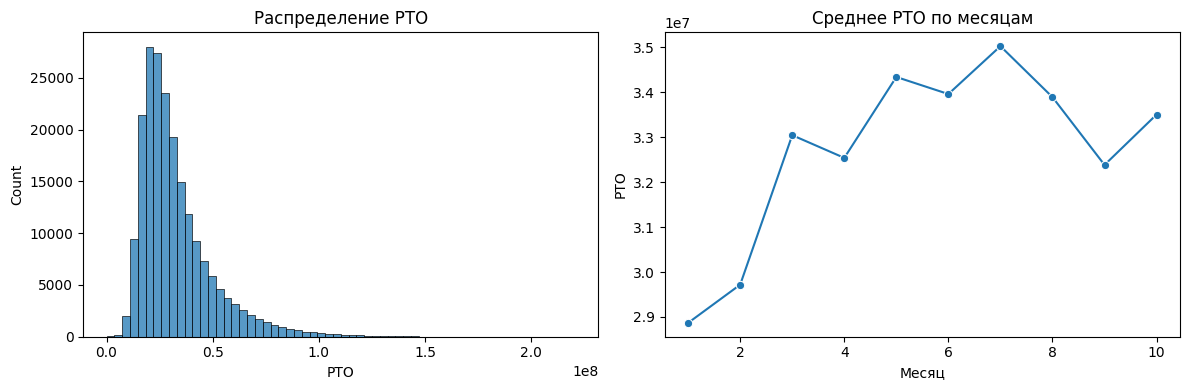

count    2.061500e+05
mean     3.272725e+07
std      1.768909e+07
min      1.619487e+04
25%      2.086432e+07
50%      2.791845e+07
75%      3.923328e+07
max      2.205870e+08
Name: РТО, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['РТО'], bins=60, ax=axes[0])
axes[0].set_title('Распределение РТО')
sns.lineplot(data=df.groupby('Месяц')['РТО'].mean().reset_index(), x='Месяц', y='РТО', ax=axes[1], marker='o')
axes[1].set_title('Среднее РТО по месяцам')
plt.tight_layout()
plt.show()

print(df['РТО'].describe())

In [3]:
num_cols = df.select_dtypes('number').columns.tolist()
corr = df[num_cols].corr()['РТО'].sort_values(ascending=False)
print(corr.head(10))

РТО                                          1.000000
Количество касс                              0.642029
Численность населения                        0.317665
Маркетплейсы, доставки, постаматы (100 м)    0.206619
Остановки (300 м)                            0.194314
Количество домохозяйств                      0.187229
Трафик пеший, в час                          0.156622
Медицинские уч. и аптеки (300 м)             0.143559
Школы (300 м)                                0.076288
Месяц                                        0.070546
Name: РТО, dtype: float64


In [4]:
df = df.sort_values(['new_id', 'Месяц']).copy()

df["rto_lag_1"] = df.groupby("new_id")["РТО"].shift(1)
df["rto_lag_2"] = df.groupby("new_id")["РТО"].shift(2)
df["rto_lag_3"] = df.groupby("new_id")["РТО"].shift(3)
df["rto_lag_6"] = df.groupby("new_id")["РТО"].shift(6)

df["rto_std_3"] = df.groupby("new_id")["РТО"].shift(1).rolling(3).std()
df["rto_mean_3"] = df.groupby("new_id")["РТО"].shift(1).rolling(3).mean()
df["rto_growth"] = df.groupby("new_id")["РТО"].pct_change()

df[[
    "rto_lag_1", "rto_lag_2", "rto_lag_3", "rto_lag_6", "rto_std_3", "rto_mean_3",
]] = df[[
    "rto_lag_1", "rto_lag_2", "rto_lag_3", "rto_lag_6", "rto_std_3", "rto_mean_3",
]].dropna()

df["rto_per_cashdesk"] = df["РТО"] / (df["Количество касс"] + 1)

df["traffic_per_store"] = (
    (df["Трафик пеший, в час"] + df["Трафик авто, в час"]) /
    (df["Продуктовые магазины (500 м)"] + 1)
)

df["population_per_store"] = df["Численность населения"] / (df["Продуктовые магазины (500 м)"] + 1)

df["lag_ratio"] = df["rto_lag_1"] / (df["rto_lag_2"] + 1)

df["traffic_per_cult"] = (
    (df["Трафик пеший, в час"] + df["Трафик авто, в час"]) /
    (df["Количество домохозяйств"] + 1)
)

region_mean_rto = df.groupby('Регион')['РТО'].transform('mean')
df['region_mean_rto'] = region_mean_rto

print(f"Строк после добавления лагов: {len(df):,}")

Строк после добавления лагов: 206,150


In [5]:
train_data = df[df["Месяц"] <= 9].copy()
test_data = df[df["Месяц"] == 10].copy()

target = "РТО"

categorical_features = [
    "Дата открытия, категориальный",
    "Торговая площадь, категориальный",
    "Регион",
]

numeric_features = [
    "Месяц", "rto_lag_1", "rto_lag_6", "rto_mean_3", "rto_growth", "lag_ratio",
    "rto_per_cashdesk", "traffic_per_store", "traffic_per_cult", "population_per_store",
    "region_mean_rto",
    'Численность населения', 'Количество домохозяйств',
    'Трафик пеший, в час', 'Трафик авто, в час',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)',
    'Остановки (300 м)', 'Продуктовые магазины (500 м)',
    'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии'
]

print(f"Train: {len(train_data):,} строк (мес. 1-9), Test: {len(test_data):,} строк (мес. 10)")

Train: 185,535 строк (мес. 1-9), Test: 20,615 строк (мес. 10)


In [6]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
oe.fit(train_data[categorical_features])

X_train_cat = oe.transform(train_data[categorical_features])
X_test_cat = oe.transform(test_data[categorical_features])

X_train_num = train_data[numeric_features].values
X_test_num = test_data[numeric_features].values

X_train = np.hstack([X_train_num, X_train_cat])
X_test = np.hstack([X_test_num, X_test_cat])

y_train = np.log1p(train_data[target].values)
y_test = np.log1p(test_data[target].values)

## Модель: Random Forest

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=41,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [8]:
from sklearn.metrics import mean_absolute_percentage_error

y_pred_rf = np.expm1(rf_model.predict(X_test))
y_test_real = np.expm1(y_test)

mape_rf = mean_absolute_percentage_error(y_test_real, y_pred_rf) * 100
print(f"MAPE (holdout, месяц 10): {mape_rf:.2f}%")

MAPE (holdout, месяц 10): 2.79%


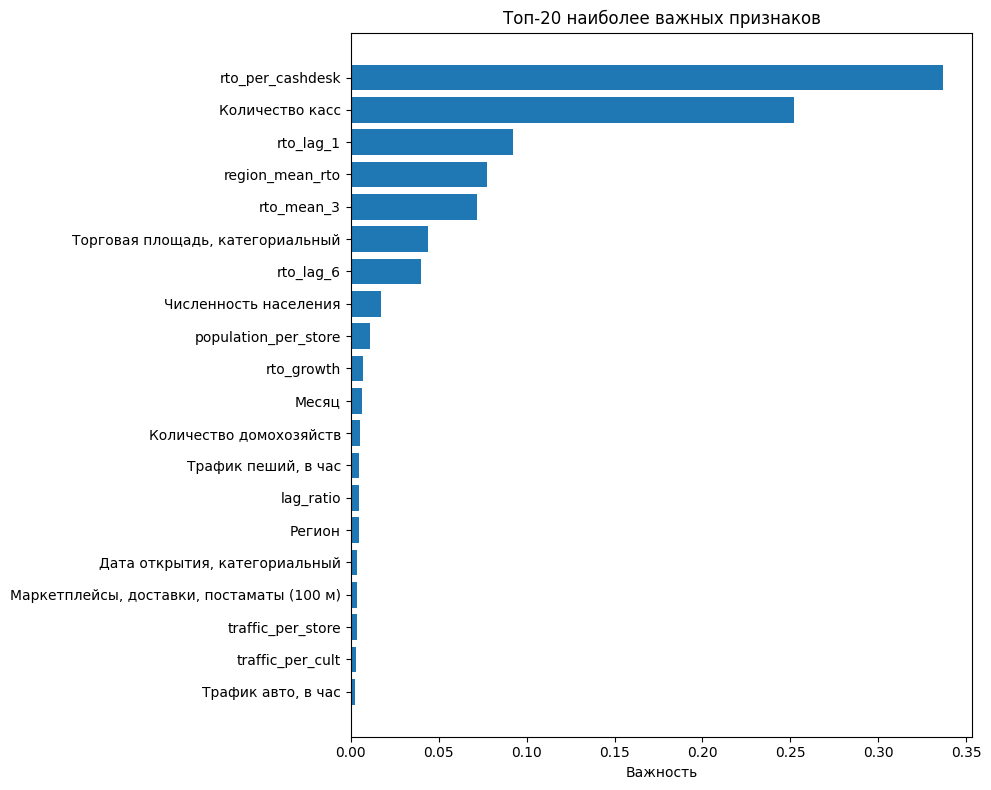

,Признак,Важность
6,rto_per_cashdesk,0.336671
21,Количество касс,0.252301
1,rto_lag_1,0.092559
10,region_mean_rto,0.077432
3,rto_mean_3,0.071862
24,"Торговая площадь, категориальный",0.043915
2,rto_lag_6,0.039684
11,Численность населения,0.017063
9,population_per_store,0.010920
4,rto_growth,0.007110


In [9]:
feature_names = numeric_features + categorical_features

feature_importance = (
    pd.DataFrame({
        "Признак": feature_names,
        "Важность": rf_model.feature_importances_
    })
    .sort_values("Важность", ascending=False)
)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["Признак"][:20][::-1],
    feature_importance["Важность"][:20][::-1]
)
plt.title("Топ-20 наиболее важных признаков")
plt.xlabel("Важность")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

display(feature_importance.head(20))